# Detrex Backend Sanity

This notebook loads the DAOD config from `configs/daod/` and verifies detrex import, model construction, checkpoint loading, DAOD inference, and the two checkpoint-loading cases when `num_classes` matches or differs.

In [1]:
from __future__ import annotations

from copy import deepcopy
from pathlib import Path
import sys

import detrex
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from detectron2.data import MetadataCatalog
from detectron2.utils.visualizer import Visualizer

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.config import load_config
from src.data.daod import build_daod_dataset
from src.models.detrex_adapter import build_daod_model, load_daod_model_config, run_daod_inference

CONFIG_PATH = REPO_ROOT / "configs/daod/source_cityscapes_to_foggy_cityscapes_dino.yaml"
cfg = load_config(CONFIG_PATH)

print(detrex.__file__)
CONFIG_PATH


/local/home/ljzhang/code/SFADA/external/detrex/detrex/layers/dcn_v3.py:23: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/local/home/ljzhang/code/SFADA/external/detrex/detrex/layers/dcn_v3.py:52: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers",

/local/home/ljzhang/code/SFADA/external/detrex/detrex/__init__.py


PosixPath('/local/home/ljzhang/code/SFADA/configs/daod/source_cityscapes_to_foggy_cityscapes_dino.yaml')

In [2]:
source_ds = build_daod_dataset(cfg, "source_val", transform=None)
target_ds = build_daod_dataset(cfg, "target_val", transform=None)
len(source_ds), len(target_ds)


(500, 500)

In [3]:
load_daod_model_config(cfg)


DetrexAdapterConfig(model_name='dino_r50_4scale_12ep', config_path='/local/home/ljzhang/code/SFADA/external/detrex/projects/dino/configs/dino-resnet/dino_r50_4scale_12ep.py', init_checkpoint='/local/home/ljzhang/code/SFADA/external/detrex/ckpts/dino_r50_4scale_12ep_49_2AP.pth', num_classes=8, min_size_test=800, max_size_test=1333)

In [4]:
adapter = build_daod_model(cfg, load_weights=True)
adapter.load_report


DetrexLoadReport(mode='partial', loaded_keys=605, missing_keys=['class_embed.0.bias', 'class_embed.0.weight', 'class_embed.1.bias', 'class_embed.1.weight', 'class_embed.2.bias', 'class_embed.2.weight', 'class_embed.3.bias', 'class_embed.3.weight', 'class_embed.4.bias', 'class_embed.4.weight', 'class_embed.5.bias', 'class_embed.5.weight', 'class_embed.6.bias', 'class_embed.6.weight', 'label_enc.weight', 'transformer.decoder.class_embed.0.bias', 'transformer.decoder.class_embed.0.weight', 'transformer.decoder.class_embed.1.bias', 'transformer.decoder.class_embed.1.weight', 'transformer.decoder.class_embed.2.bias', 'transformer.decoder.class_embed.2.weight', 'transformer.decoder.class_embed.3.bias', 'transformer.decoder.class_embed.3.weight', 'transformer.decoder.class_embed.4.bias', 'transformer.decoder.class_embed.4.weight', 'transformer.decoder.class_embed.5.bias', 'transformer.decoder.class_embed.5.weight', 'transformer.decoder.class_embed.6.bias', 'transformer.decoder.class_embed.6.w

In [5]:
sample_batch = [source_ds[0], target_ds[0]]
for sample in sample_batch:
    assert Path(sample["file_name"]).exists()
    assert sample["height"] > 0 and sample["width"] > 0
    assert isinstance(sample["annotations"], list)
sample_batch[0]


{'sample_id': 'source_val:frankfurt:frankfurt_000000_000294',
 'file_name': '/home/ljzhang/data/ins-seg/cityscapes/leftImg8bit/val/frankfurt/frankfurt_000000_000294_leftImg8bit.png',
 'image_id': 'source_val:frankfurt:frankfurt_000000_000294',
 'height': 1024,
 'width': 2048,
 'annotations': [{'bbox': [949.0, 406.0, 965.0, 445.0],
   'bbox_mode': 0,
   'category_id': 0,
   'segmentation': [[960.0,
     444.0,
     960.0,
     439.0,
     960.0,
     430.0,
     961.0,
     428.0,
     964.0,
     428.0,
     965.0,
     425.0,
     965.0,
     421.0,
     962.0,
     418.0,
     959.0,
     415.0,
     958.0,
     411.0,
     957.0,
     409.0,
     955.0,
     406.0,
     955.0,
     406.0,
     954.0,
     406.0,
     951.0,
     408.0,
     949.0,
     413.0,
     949.0,
     419.0,
     951.0,
     430.0,
     952.0,
     433.0,
     952.0,
     435.0,
     954.0,
     440.0,
     954.0,
     442.0,
     954.0,
     443.0,
     955.0,
     445.0,
     959.0,
     445.0]],
   'iscro

In [6]:
outputs = run_daod_inference(adapter, sample_batch)
len(outputs), outputs[0].keys()


/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


(2, dict_keys(['sample_id', 'file_name', 'prediction']))

In [7]:
instances = outputs[0]["prediction"]["instances"].to("cpu")
print("num predictions:", len(instances))
print("scores shape:", tuple(instances.scores.shape))
instances


num predictions: 300
scores shape: (300,)


Instances(num_instances=300, image_height=1024, image_width=2048, fields=[pred_boxes: Boxes(tensor([[1.1571e+03, 3.9971e+02, 1.1739e+03, 4.6734e+02],
        [1.6449e+03, 1.6603e+02, 1.6679e+03, 1.8922e+02],
        [2.0415e+03, 8.8505e+02, 2.0480e+03, 1.0202e+03],
        ...,
        [5.7700e+02, 4.6417e+02, 5.9334e+02, 4.8851e+02],
        [1.1900e+03, 1.6719e+00, 1.3446e+03, 1.6212e+02],
        [0.0000e+00, 4.5883e+01, 3.9990e+02, 1.0039e+03]])), scores: tensor([0.0478, 0.0455, 0.0446, 0.0443, 0.0424, 0.0420, 0.0419, 0.0418, 0.0415,
        0.0413, 0.0412, 0.0407, 0.0405, 0.0405, 0.0404, 0.0402, 0.0394, 0.0391,
        0.0390, 0.0390, 0.0389, 0.0389, 0.0388, 0.0387, 0.0387, 0.0385, 0.0384,
        0.0383, 0.0382, 0.0380, 0.0379, 0.0378, 0.0376, 0.0374, 0.0374, 0.0373,
        0.0372, 0.0370, 0.0369, 0.0369, 0.0366, 0.0365, 0.0365, 0.0365, 0.0364,
        0.0364, 0.0363, 0.0362, 0.0362, 0.0362, 0.0362, 0.0361, 0.0361, 0.0361,
        0.0360, 0.0360, 0.0359, 0.0358, 0.0357, 0.0357, 

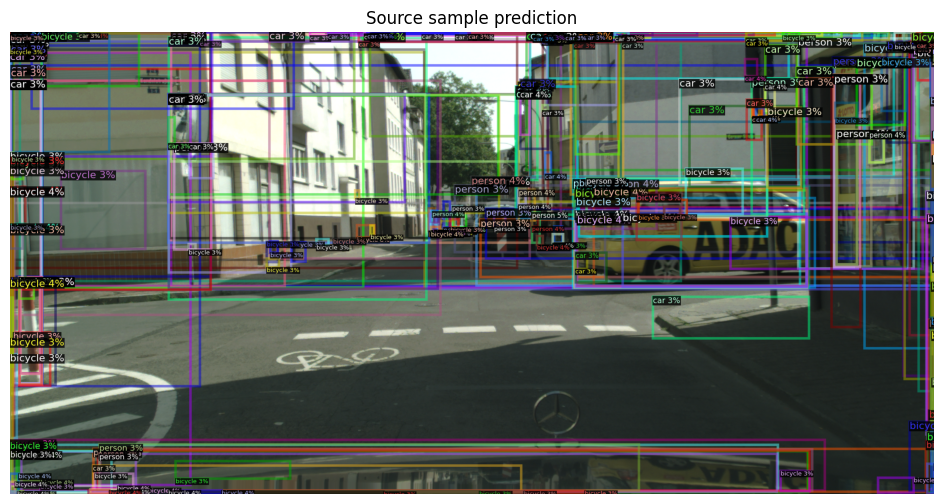

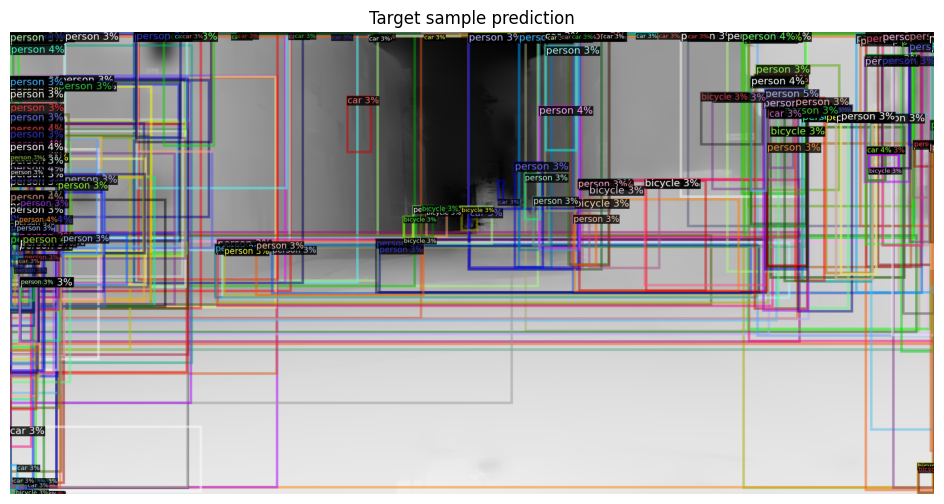

In [8]:
metadata = MetadataCatalog.get("daod_model_sanity")
metadata.set(thing_classes=list(source_ds.thing_classes))

def visualize(sample, output, title):
    image = np.asarray(Image.open(sample["file_name"]).convert("RGB"))
    vis = Visualizer(image, metadata=metadata)
    rendered = vis.draw_instance_predictions(output["prediction"]["instances"].to("cpu")).get_image()
    plt.figure(figsize=(12, 6))
    plt.imshow(rendered)
    plt.title(title)
    plt.axis("off")


visualize(sample_batch[0], outputs[0], "Source sample prediction")
visualize(sample_batch[1], outputs[1], "Target sample prediction")


## Num Classes Load Check

In [ ]:
cfg_full = deepcopy(cfg)
cfg_partial = deepcopy(cfg)
cfg_full.data.num_classes = 80
cfg_partial.data.num_classes = 8

adapter_full = build_daod_model(cfg_full, load_weights=True)
adapter_partial = build_daod_model(cfg_partial, load_weights=True)

print("full:", adapter_full.load_report)
print("partial:", adapter_partial.load_report)

assert adapter_full.load_report.mode == "full"
assert adapter_partial.load_report.mode == "partial"


In [ ]:
outputs_full = run_daod_inference(adapter_full, [source_ds[0]])
outputs_partial = run_daod_inference(adapter_partial, [source_ds[0]])

instances_full = outputs_full[0]["prediction"]["instances"].to("cpu")
instances_partial = outputs_partial[0]["prediction"]["instances"].to("cpu")

print("full predictions:", len(instances_full))
print("partial predictions:", len(instances_partial))
if len(instances_partial):
    print("partial pred class max:", int(instances_partial.pred_classes.max()))
    assert int(instances_partial.pred_classes.max()) < cfg_partial.data.num_classes
